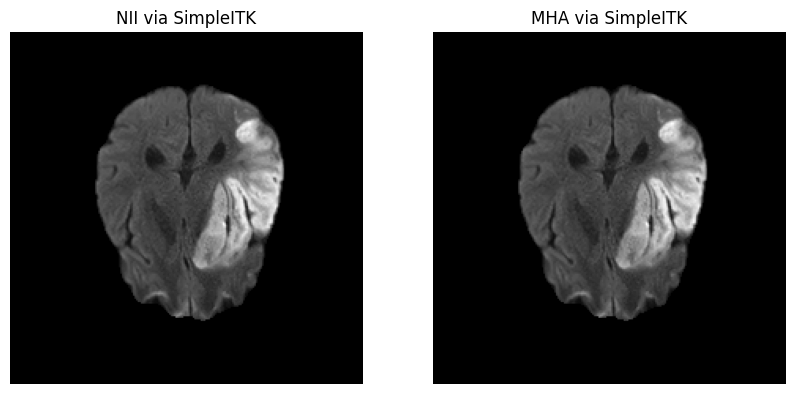

same shape: True
same voxels: True


In [51]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
import numpy as np

nii_path = "/mnt/disk1/SOOP_TRACE_STRIPPED/sub-1010_rec-TRACE_dwi.nii.gz"
mha_path = "/mnt/disk1/hieupc/4gpus-Stroke-outcome-prediction-code/code/segmentor/ISLES22_SEALS/input/sub-1010/dwi-brain-mri/dwi.mha"

nii_img = sitk.ReadImage(nii_path)
mha_img = sitk.ReadImage(mha_path)

nii_arr = sitk.GetArrayFromImage(nii_img)   # (z, y, x)
mha_arr = sitk.GetArrayFromImage(mha_img)   # (z, y, x)

z = nii_arr.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(nii_arr[z], cmap="gray")
axes[0].set_title("NII via SimpleITK")
axes[0].axis("off")

axes[1].imshow(mha_arr[z], cmap="gray")
axes[1].set_title("MHA via SimpleITK")
axes[1].axis("off")

plt.show()

print("same shape:", nii_arr.shape == mha_arr.shape)
print("same voxels:", np.array_equal(nii_arr, mha_arr))

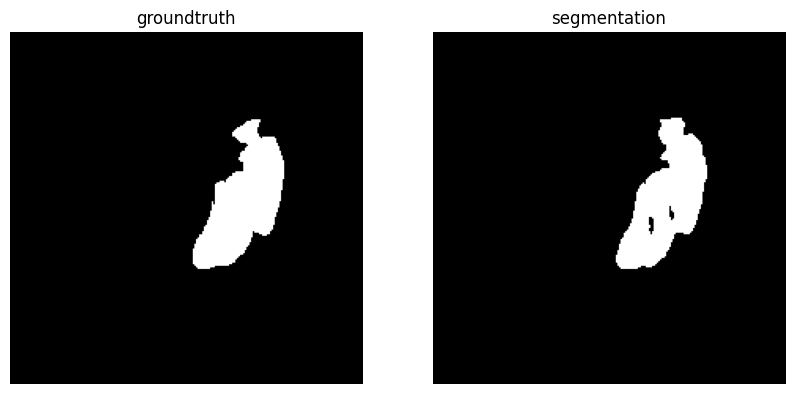

same shape: True
same voxels: False


In [52]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
import numpy as np

nii_path = "/mnt/disk1/SOOP_raw/derivatives/lesion_masks/sub-1010/dwi/sub-1010_space-TRACE_desc-lesion_mask.nii.gz"
mha_path = "/mnt/disk1/hieupc/4gpus-Stroke-outcome-prediction-code/code/segmentor/ISLES22_SEALS/output/batch/images/stroke-lesion-segmentation/sub-1010.mha"

nii_img = sitk.ReadImage(nii_path)
mha_img = sitk.ReadImage(mha_path)

nii_arr = sitk.GetArrayFromImage(nii_img)   # (z, y, x)
mha_arr = sitk.GetArrayFromImage(mha_img)   # (z, y, x)

z = nii_arr.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(nii_arr[z], cmap="gray")
axes[0].set_title("groundtruth")
axes[0].axis("off")

axes[1].imshow(mha_arr[z], cmap="gray")
axes[1].set_title("segmentation")
axes[1].axis("off")

plt.show()

print("same shape:", nii_arr.shape == mha_arr.shape)
print("same voxels:", np.array_equal(nii_arr, mha_arr))

In [53]:
import os  

print(len(os.listdir("/mnt/disk1/hieupc/4gpus-Stroke-outcome-prediction-code/code/segmentor/ISLES22_SEALS/output/batch/images/stroke-lesion-segmentation/")))

623


In [54]:
segmendted = os.listdir("/mnt/disk1/hieupc/4gpus-Stroke-outcome-prediction-code/code/segmentor/ISLES22_SEALS/output/batch/images/stroke-lesion-segmentation")
# second_segmendted = os.listdir("/mnt/disk1/hieupc/4gpus-Stroke-outcome-prediction-code/code/segmentor/ISLES22_SEALS/output/batch_resume/images/stroke-lesion-segmentation/")

In [55]:
done_subjects = set()
for subject_file in segmendted:
    done_subjects.add(subject_file.split(".")[0])
# for subject_file in second_segmendted:
#     done_subjects.add(subject_file.split(".")[0])

In [56]:
done_subjects

{'result',
 'sub-100',
 'sub-1001',
 'sub-1003',
 'sub-1005',
 'sub-1010',
 'sub-1011',
 'sub-1012',
 'sub-1013',
 'sub-1014',
 'sub-1015',
 'sub-1016',
 'sub-1019',
 'sub-1024',
 'sub-1025',
 'sub-1026',
 'sub-1029',
 'sub-1035',
 'sub-1039',
 'sub-1041',
 'sub-1043',
 'sub-1047',
 'sub-1050',
 'sub-1052',
 'sub-1056',
 'sub-1057',
 'sub-1067',
 'sub-1068',
 'sub-1073',
 'sub-1075',
 'sub-1076',
 'sub-1077',
 'sub-108',
 'sub-1081',
 'sub-1083',
 'sub-1084',
 'sub-1086',
 'sub-1087',
 'sub-1092',
 'sub-110',
 'sub-1100',
 'sub-1102',
 'sub-1104',
 'sub-1107',
 'sub-1109',
 'sub-111',
 'sub-1115',
 'sub-1117',
 'sub-1118',
 'sub-1120',
 'sub-1121',
 'sub-1122',
 'sub-1127',
 'sub-1128',
 'sub-1129',
 'sub-113',
 'sub-1130',
 'sub-1131',
 'sub-1136',
 'sub-1137',
 'sub-1140',
 'sub-1144',
 'sub-1147',
 'sub-1148',
 'sub-1150',
 'sub-1158',
 'sub-116',
 'sub-1160',
 'sub-1165',
 'sub-1169',
 'sub-1171',
 'sub-1175',
 'sub-118',
 'sub-1181',
 'sub-1182',
 'sub-1183',
 'sub-1185',
 'sub-11

In [57]:
import pandas as pd 

df = pd.read_csv("/mnt/disk1/hieupc/4gpus-Stroke-outcome-prediction-code/code/utils/SOOP_modalities_dataset.csv")
list_subjects = set(df["[subject_id"].tolist())

In [58]:
remaining_sub = list_subjects - done_subjects

In [59]:
print(len(remaining_sub))

0


In [60]:
remain = pd.DataFrame({"subject_id": list(remaining_sub)})

In [61]:
# remain.to_csv("/mnt/disk1/hieupc/4gpus-Stroke-outcome-prediction-code/code/utils/remaining_subjects.csv", index=False)